In [34]:
#from google.colab import drive
#drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt
from  matplotlib.lines import Line2D

import numpy as np
import numpy.lib.recfunctions as rfn
from   numpy.polynomial.legendre import legval

import plotly.graph_objects as go
from ipywidgets import interact, IntSlider

from scipy.special import eval_legendre,legendre,factorial
from scipy.optimize import curve_fit, least_squares, differential_evolution

import pickle

from decimal import Decimal

# Import des données

In [16]:
# Tableau : He-HCN
He = np.genfromtxt("Data/He-HCN.txt",
                   delimiter=",", names=True, dtype=None, encoding="utf-8")

params_He = np.array([ 1.69637,    0.18540,   0.19384,  -0.01302, -0.00719,-0.02571, # b
                      -19454.791, -23297.750,-9250.9937,-45021.967,                  # c
                       11.90598,   1.33541,   2.23321,   0.31214,  0.06321,-0.13334, # d
                       0.12724,   -0.36813,  -0.18070,   0.00010,  0.24256,-0.00422, # g0
                       0.05486,    0.08842,   0.06785,  -0.01495, -0.11374, 0.02042, # g1
                      -0.01311,    0.00038,  -0.00099,   0.00252,  0.01929,-0.00554, # g2
                       0.00053,   -0.00076,  -0.00059,   0.00002, -0.00112, 0.00036])# g3

# Conversion des µEh en mEh
energy_mEh = He['Energy'] * 1e-3
# Ajout de la colonne en Eh
He = rfn.append_fields(He, names='Energy_mEh', data=energy_mEh, usemask=False)

# Implémentation des fonctions

In [17]:
def f6_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x / 720.0)))))
  return 1.0 - np.exp(-x) * y

def f7_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x * (1.0/720.0 + x / 5040.0))))))
  return 1.0 - np.exp(-x) * y

In [18]:
def V_opt(p, R, Theta):
  R = np.asarray(R, dtype=float)
  # On calcule ces valeurs car utiles plusieurs fois
  cosTh = np.cos(np.deg2rad(np.asarray(Theta, dtype=float)))

  # Paramètres
  b  = p[0:6]                            # b0, b1, b2, b3, b4, b5
  c  = p[6:10]                           # c0, c1, c2, c3
  d  = p[10:16]                          # d0, d1, d2, d3, d4, d5
  g0 = np.asarray(p[16:22], dtype=float) # g00, g01, g02, g03, g04, g05
  g1 = np.asarray(p[22:28], dtype=float) # g10, g11, g12, g13, g14, g15
  g2 = np.asarray(p[28:34], dtype=float) # g20, g21, g22, g23, g24, g25
  g3 = np.asarray(p[34:40], dtype=float) # g30, g31, g32, g33, g34, g35

  # X(theta) ------------------------------------ #
  # --------------------------------------------- #
  X_b = legval(cosTh, b)
  X_d = legval(cosTh, d)

  X_bR = X_b * R
  abs_BR = np.abs(X_bR)
  # --------------------------------------------- #

  # G(R,theta) ---------------------------------- #
  # --------------------------------------------- #
  i = np.arange(6)
  g = g0[i, None] + R * (g1[i, None] + R * (g2[i, None] + R * g3[i, None]))
  Pl = np.array([eval_legendre(l, cosTh) for l in range(6)])
  # G = np.sum(g * Pl, axis=0)
  # ------------------------------------------- #

  # Short-Range
  exp_val = np.clip(X_d-X_bR,-200,200) # Bloquage des valeurs trop grandes/petites
  V_sh = np.sum(g * Pl, axis=0) * np.exp(exp_val)

  # Asymptotic
  inv_R = 1.0/R
  inv_R6 = inv_R * inv_R * inv_R * inv_R * inv_R * inv_R
  inv_R7 = inv_R6 * inv_R

  V_as = (f6_opt(abs_BR) * legval(cosTh,[c[0],0,c[2]]) * inv_R6
        + f7_opt(abs_BR) * legval(cosTh,[0,c[1],0,c[3]]) * inv_R7)

  V_total = V_sh + V_as

  # Pour ne pas renvoyer NaN en cas d'erreur
  V_total = np.nan_to_num(V_total, nan=1e100, posinf=1e100, neginf=-1e100)
  # Bloquage des valeurs trop grandes
  V_total = np.clip(V_total, -1e100, 1e100)
  
  return V_total # Energie renvoyée en mEh

# Fonctions de métriques

In [19]:
def rsq(y, f):
  y = np.asarray(y)
  f = np.asarray(f)
  stot = np.sum((y-np.mean(y))**2)
  sres = np.sum((y-f)**2)
  return 1.0 - sres/stot


# y == valeurs tabulées

# f == f(x, y, popt)

In [20]:
def rmse(y, f):
    y = np.asarray(y)
    f = np.asarray(f)
    return np.sqrt(np.mean((y-f)**2))

In [21]:
def mae(y,f):
    y = np.asarray(y)
    f = np.asarray(f)
    return np.mean(np.abs(y-f))

# Fonction d'affichage

In [22]:
def plot_interactif(
    model,
    params,
    fixed_vals,
    x,
    data,
    fixed_col,
    x_col,
    y_col,
    title="Graphique interactif",
    fixed_first=True
):

    fig = go.Figure()

    for i, val in enumerate(fixed_vals):

        # ordre des variables
        if fixed_first:
            y_model = model(params, np.full_like(x, val), x)
        else:
            y_model = model(params, x, np.full_like(x, val))

        # données
        mask = np.isclose(data[fixed_col], val)

        x_data = data[x_col][mask]
        y_data = data[y_col][mask]

        order = np.argsort(x_data)

        visible = (i == 0)

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y_model,
                mode='lines',
                name='Modèle',
                visible=visible
            )
        )

        fig.add_trace(
            go.Scatter(
                x=x_data[order],
                y=y_data[order],
                mode='markers',
                name='Données',
                visible=visible
            )
        )

    steps = []

    for i, val in enumerate(fixed_vals):

        vis = [False] * (2 * len(fixed_vals))

        vis[2*i] = True
        vis[2*i+1] = True

        steps.append(
            dict(
                method="update",
                args=[
                    {"visible": vis},
                    {"title": f"{fixed_col} = {val}"}
                ],
                label=str(val)
            )
        )

    fig.update_layout(
        title=title,
        sliders=[dict(steps=steps)],
        template="plotly_white",
        width=600,
        height=400,
        uirevision=True
    )

    fig.show()

# Méthode 1 : curve_fit

In [23]:
def V_curvefit(vars, *p):
    R, Theta = vars
    return V_opt(p, R, Theta)

## He-HCN

### Calculs

In [24]:
R = np.asarray(He["R"], dtype=float)
Theta = np.asarray(He["Theta"], dtype=float)
V_table = np.asarray(He["Energy"], dtype=float)
V_table_mEh = np.asarray(He["Energy_mEh"], dtype=float)
R.shape, Theta.shape, V_table.shape

((138,), (138,), (138,))

In [25]:
#params_init_cf = 10 * np.random.rand(40) - 5
#print(params_init_cf)
params_opt_cf, params_cov = curve_fit(V_curvefit, (R, Theta), V_table_mEh,
                                      p0=params_He, maxfev=1000000,
                                      method="lm")
params_opt_cf_sigma, params_cov = curve_fit(V_curvefit, (R, Theta), V_table_mEh,
                                      p0=params_He, maxfev=1000000,
                                      method="lm", sigma=V_table_mEh)

In [26]:
b  = params_opt_cf[0:6]   # b0, b1, b2, b3, b4, b5
c  = params_opt_cf[6:10]  # c0, c1, c2, c3
d  = params_opt_cf[10:16] # d0, d1, d2, d3, d4, d5
g0 = params_opt_cf[16:22] # g00, g01, g02, g03, g04, g05
g1 = params_opt_cf[22:28] # g10, g11, g12, g13, g14, g15
g2 = params_opt_cf[28:34] # g20, g21, g22, g23, g24, g25
g3 = params_opt_cf[34:40] # g30, g31, g32, g33, g34, g35

print(f"[b0,b1,b2,b3,b4,b5]       = [{b[0]}, {b[1]}, {b[2]}, {b[3]}, {b[4]}, {b[5]}]")
print(f"[c0,c1,c2,c3]             = [{c[0]}, {c[1]}, {c[2]}, {c[3]}]")
print(f"[d0,d1,d2,d3,d4,d5]       = [{d[0]}, {d[1]}, {d[2]}, {d[3]}, {d[4]}, {d[5]}]")
print(f"[g00,g01,g02,g03,g04,g05] = [{g0[0]}, {g0[1]}, {g0[2]}, {g0[3]}, {g0[4]}, {g0[5]}]")
print(f"[g10,g11,g12,g13,g14,g15] = [{g1[0]}, {g1[1]}, {g1[2]}, {g1[3]}, {g1[4]}, {g1[5]}]")
print(f"[g20,g21,g22,g23,g24,g25] = [{g2[0]}, {g2[1]}, {g2[2]}, {g2[3]}, {g2[4]}, {g2[5]}]")
print(f"[g30,g31,g32,g33,g34,g35] = [{g3[0]}, {g3[1]}, {g3[2]}, {g3[3]}, {g3[4]}, {g3[5]}]")

[b0,b1,b2,b3,b4,b5]       = [2.169765952790554, -0.8565434705378945, 0.544245401254734, -0.06351702684400573, -0.1470101966140648, -0.047869800971802295]
[c0,c1,c2,c3]             = [-19934.52684741333, -23123.138901373775, -10582.817297477468, -17849.922534069687]
[d0,d1,d2,d3,d4,d5]       = [16.857848683132456, -4.504673913795543, 4.690365026377471, -0.05681414217337836, -0.5842162412282115, -0.20186790284646583]
[g00,g01,g02,g03,g04,g05] = [-0.042368810494733754, 0.09201298634531191, -0.1655066508014071, 0.17226629735821936, -0.08277601800556757, 0.08345637225468927]
[g10,g11,g12,g13,g14,g15] = [0.03131213424120493, -0.05041035537152316, 0.0999111162257008, -0.10571180051494397, 0.05391912456779295, -0.039101473786020274]
[g20,g21,g22,g23,g24,g25] = [-0.006227845489729276, 0.011081576860289283, -0.020911012020728616, 0.021326246320441108, -0.010995274343293313, 0.00597131359245722]
[g30,g31,g32,g33,g34,g35] = [0.00042373487280468355, -0.0008949252598476858, 0.001489301915454638, -0.

In [27]:
print(params_opt_cf)
print(params_opt_cf_sigma)

[ 2.16976595e+00 -8.56543471e-01  5.44245401e-01 -6.35170268e-02
 -1.47010197e-01 -4.78698010e-02 -1.99345268e+04 -2.31231389e+04
 -1.05828173e+04 -1.78499225e+04  1.68578487e+01 -4.50467391e+00
  4.69036503e+00 -5.68141422e-02 -5.84216241e-01 -2.01867903e-01
 -4.23688105e-02  9.20129863e-02 -1.65506651e-01  1.72266297e-01
 -8.27760180e-02  8.34563723e-02  3.13121342e-02 -5.04103554e-02
  9.99111162e-02 -1.05711801e-01  5.39191246e-02 -3.91014738e-02
 -6.22784549e-03  1.10815769e-02 -2.09110120e-02  2.13262463e-02
 -1.09952743e-02  5.97131359e-03  4.23734873e-04 -8.94925260e-04
  1.48930192e-03 -1.41505490e-03  7.09079469e-04 -2.97066025e-04]
[ 1.51786526e+00 -1.30933789e-01  3.60656910e-01 -2.52724150e-01
 -1.10216645e-05  1.00312732e-02 -1.73071242e+04 -2.20629744e+04
 -8.64027390e+03 -7.24675963e+03  1.19657531e+01 -2.26777571e+00
  4.18670880e+00 -1.31711689e+00  5.32941408e-01  2.87288266e-02
  4.86536984e-01  5.40069560e-01 -4.03152385e-02  1.75310005e-01
  3.17269064e-01  1.9160

In [38]:
print(np.array2string(
    params_opt_cf_sigma,
    formatter={'float_kind': lambda x: f"{x:.12f}"}
))

[1.517865255645 -0.130933788665 0.360656910101 -0.252724149617
 -0.000011021664 0.010031273183 -17307.124225786836 -22062.974364099526
 -8640.273898846215 -7246.759634217336 11.965753107735 -2.267775707301
 4.186708800528 -1.317116888544 0.532941407840 0.028728826640
 0.486536984494 0.540069560462 -0.040315238526 0.175310005496
 0.317269064063 0.019160524647 -0.126895949832 -0.120537568155
 0.046839116732 -0.076805627804 -0.147900338887 -0.015367834558
 0.011277782888 0.008178886980 -0.008372492097 0.010221158916
 0.020682387045 0.002388452363 -0.000410660483 -0.000228684413
 0.000408139695 -0.000397414775 -0.000884554787 -0.000093138417]
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [28]:
# Evaluation de la qualité du fit pour He-HCN
V_pred_cf = V_opt(params_opt_cf, R, Theta)
V_pred_cf_sigma = V_opt(params_opt_cf_sigma, R, Theta)
V_params_these = V_opt(params_He, R, Theta)

r2_cf = rsq(V_table_mEh, V_pred_cf)
r2_cf_sigma = rsq(V_table_mEh, V_pred_cf_sigma)
r2_params_these = rsq(V_table_mEh, V_params_these)

rmse_cf = rmse(V_table_mEh, V_pred_cf)
rmse_cf_sigma = rmse(V_table_mEh, V_pred_cf_sigma)
rmse_params_these = rmse(V_table_mEh, V_params_these)

mae_cf = mae(V_table_mEh, V_pred_cf)
mae_cf_sigma = mae(V_table_mEh, V_pred_cf_sigma)
mae_params_these = mae(V_table_mEh, V_params_these)

print(f"R² (sans sigma)         : {r2_cf}")
print(f"R² (avec sigma=y)       : {r2_cf_sigma}")
print(f"R² (paramètres these)   : {r2_params_these}")
print()
print(f"rmse (sans sigma)       : {rmse_cf}")
print(f"rmse (avec sigma=y)     : {rmse_cf_sigma}")
print(f"rmse (paramètres these) : {rmse_params_these}")
print()
print(f"mae (sans sigma)        : {mae_cf}")
print(f"mae (avec sigma=y)      : {mae_cf_sigma}")
print(f"mae (paramètres these)  : {mae_params_these}")

R² (sans sigma)         : 0.9999999124652853
R² (avec sigma=y)       : 0.9950312027803274
R² (paramètres these)   : 0.7536818940425544

rmse (sans sigma)       : 0.0006095942646987549
rmse (avec sigma=y)     : 0.14523669199736106
rmse (paramètres these) : 1.0225837339273804

mae (sans sigma)        : 0.00044046063848190856
mae (avec sigma=y)      : 0.02253799041581995
mae (paramètres these)  : 0.09172435620735991


In [39]:
R_list = [4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 10.0, 12.0]
Theta_list = [0, 20, 40, 60, 80, 90, 100, 120, 140, 160, 180]

In [45]:
# Configuration des largeurs de colonnes pour un alignement parfait
largeur_r = 10  # Largeur pour la colonne de gauche 'R \ Theta'
largeur_th = 12  # Largeur pour chaque colonne de données
nb_colonnes = len(Theta_list)

# Ligne de séparation (|-------...-------|)
ligne_separation = (
    "|" + "-" * (largeur_r + nb_colonnes * (largeur_th + 1)) + "|"
)

# 1. Affichage de l'entête
print(ligne_separation)
entete_cols = "".join(f" {th:>{largeur_th}}" for th in Theta_list)
print(f"|{'R \\ Theta |':<{largeur_r}}{entete_cols} |")
print(ligne_separation)

# 2. Remplissage et affichage des lignes de données
for r in R_list:
    # Début de la ligne avec la valeur de R bien centrée/alignée
    ligne_str = f"|  {r:<{largeur_r-2}.1f}|"

    for th in Theta_list:
        # Calcul et conversion mEh -> µEh
        res = V_opt(params_opt_cf_sigma, r, th) * 1000

        # Sécurité pour extraire le scalaire du tableau NumPy
        val_uEh = res.flatten()[0] if isinstance(res, np.ndarray) else res

        # Affichage direct de la valeur à 4 décimales, calée à droite
        ligne_str += f" {val_uEh:>{largeur_th}.4f}"

    ligne_str += " |"
    print(ligne_str)

# 3. Affichage de la ligne de fin
print(ligne_separation)

|---------------------------------------------------------------------------------------------------------------------------------------------------------|
|R \ Theta |            0           20           40           60           80           90          100          120          140          160          180 |
|---------------------------------------------------------------------------------------------------------------------------------------------------------|
|  4.5     |  152222.9002   86546.0007   26848.3842   12081.2249   11956.6426   14771.4687   20378.0949   59710.6292  361818.7332 2653292.8178 6549296.9080 |
|  5.0     |   54026.6927   30166.4234    8937.1442    3985.8788    4319.1811    5580.7844    7877.9065   22016.6385  114128.4885  704403.7072 1614977.0344 |
|  5.5     |   18353.8035    9988.1885    2721.1417    1157.6890    1436.2016    1977.3526    2886.0597    7765.6689   34647.7273  180528.7329  384662.5691 |
|  6.0     |    5797.4242    3014.9023     669.8089     

# Affichage des résultats

## Plot à variable fixée

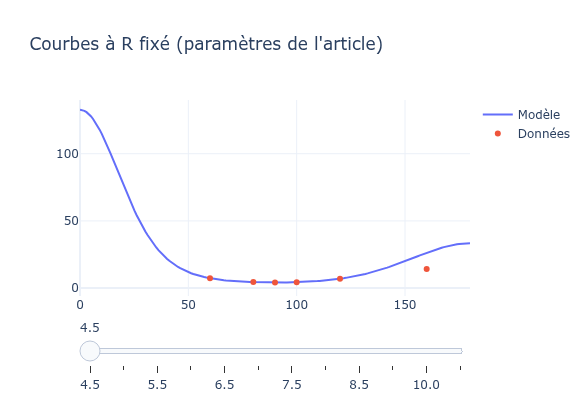

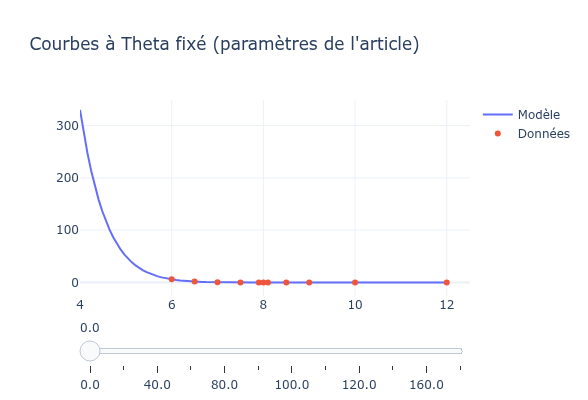

In [29]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_He, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé (paramètres de l'article)")
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_He, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé (paramètres de l'article)",fixed_first=False)

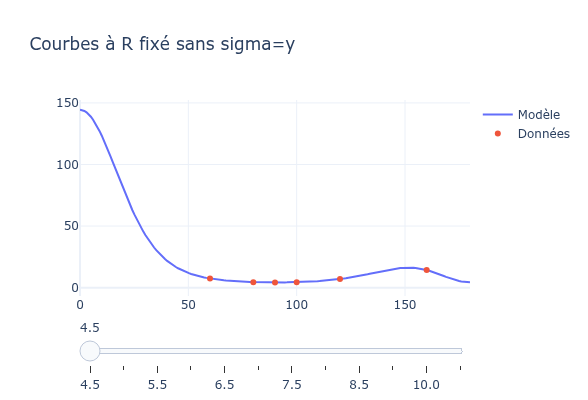

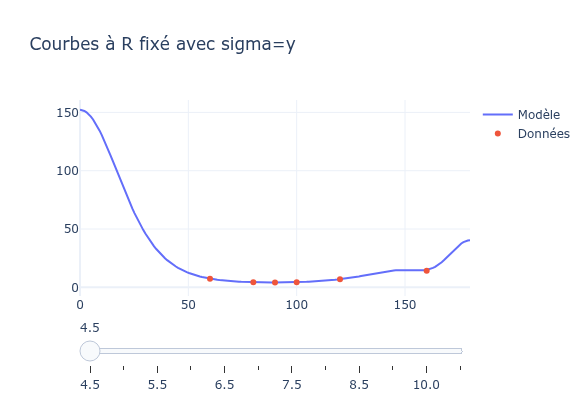

In [30]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_cf, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans sigma=y")
plot_interactif(V_opt, params_opt_cf_sigma, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec sigma=y")

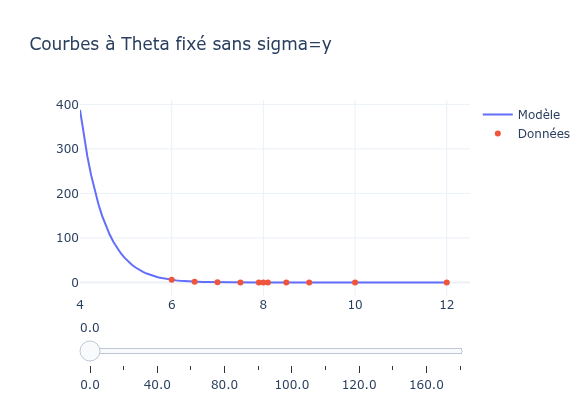

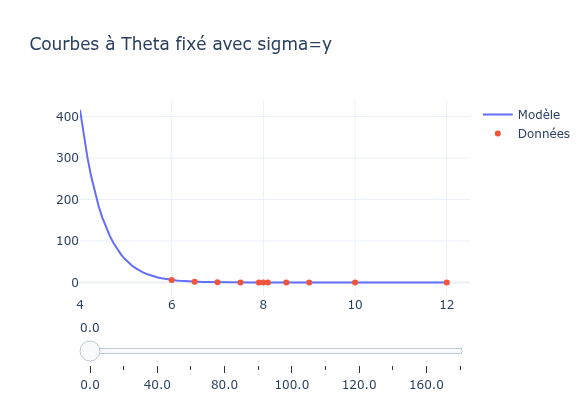

In [31]:
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_opt_cf, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé sans sigma=y",fixed_first=False)
plot_interactif(V_opt, params_opt_cf_sigma, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé avec sigma=y",fixed_first=False)

## Contour plot

In [163]:
def contour_plot(ax, params, title):
    # Axes
    theta_grid = np.linspace(0, 180, 250)
    r_grid = np.linspace(6, 10, 250)
    
    Theta_mesh, R_mesh = np.meshgrid(theta_grid, r_grid)
    
    # Calcul de Z
    Z = np.array([
        V_opt(params, np.full_like(theta_grid, r), theta_grid)
        for r in r_grid
    ])
    
    # Niveaux
    levels_to_plot = np.array([
        -0.026, -0.039,-0.051, -0.063, -0.075, -0.087,
        -0.094, -0.100, -0.112, -0.124, -0.133
    ])
    
    levels_with_labels = levels_to_plot
    
    # niveaux intermédiaires
    levels_fine = []
    for i in range(len(levels_to_plot) - 1):
        a, b = levels_to_plot[i], levels_to_plot[i + 1]
        inter = np.linspace(a, b, 6)
        levels_fine.extend(inter[1:-1])
    
    levels_fine = np.sort(np.unique(levels_fine))
    
    # Contours gris
    ax.contour(
        Theta_mesh, R_mesh, Z,
        levels=levels_fine,
        colors='gray',
        linewidths=0.7
    )
    
    # Contours principaux
    all_contours = []
    for level in levels_to_plot:
        cp = ax.contour(
            Theta_mesh, R_mesh, Z,
            levels=[level],
            colors='black',
            linewidths=1.5,
            linestyles='--'
        )
        all_contours.append(cp)
    
    # Labels
    for cp in all_contours:
        level = cp.levels[0]
        if np.isclose(levels_with_labels, level).any():
            ax.clabel(cp, fmt='%.3f', fontsize=10, inline=True)

    r_values = [6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
    theta_dense = np.linspace(0, 180, 500) # Grille dense pour trouver le minimum avec précision

    # Affichage des Max et Min selon le R
    for r_val in r_values:
        energies = V_opt(params, np.full_like(theta_dense, r_val), theta_dense)

        # Minimum
        min_idx = np.argmin(energies)
        min_E = energies[min_idx]
        min_theta = theta_dense[min_idx]
        # Maximum
        max_idx = np.argmax(energies)
        max_E = energies[max_idx]
        max_theta = theta_dense[max_idx]
        
        # Affichage du point
        ax.plot(min_theta, r_val, marker='v', color='red', markersize=5)
        ax.plot(max_theta, r_val, marker='^', color='blue', markersize=5)
        
        # Affichage de la valeur
        ax.text(min_theta + 3, r_val, f"{min_E:.3f}", color='red', 
                fontsize=9, verticalalignment='center')
        ax.text(max_theta + 3, r_val, f"{max_E:.3f}", color='blue', 
                fontsize=9, verticalalignment='center')
    
    ax.set_title(f"He-HCN - Energie potentielle (mEh)\n{title}")
    ax.set_xlabel("Theta (°)")
    ax.set_ylabel("R")
    
    ax.set_yticks(np.arange(6, 10.5, 0.5))
    ax.set_xticks(np.arange(0, 181, 30))
    
    ax.grid(True, linestyle='--', alpha=0.3)

    legende_point1 = Line2D([0], [0], linestyle='None', marker='v', color='red', 
                           markersize=5, label="Energie min")
    legende_point2 = Line2D([0], [0], linestyle='None', marker='^', color='blue', 
                           markersize=5, label="Energie max")
    legende_point = [legende_point2, legende_point1]
    ax.legend(handles=legende_point,loc='upper right', fontsize=10, framealpha=0.9)

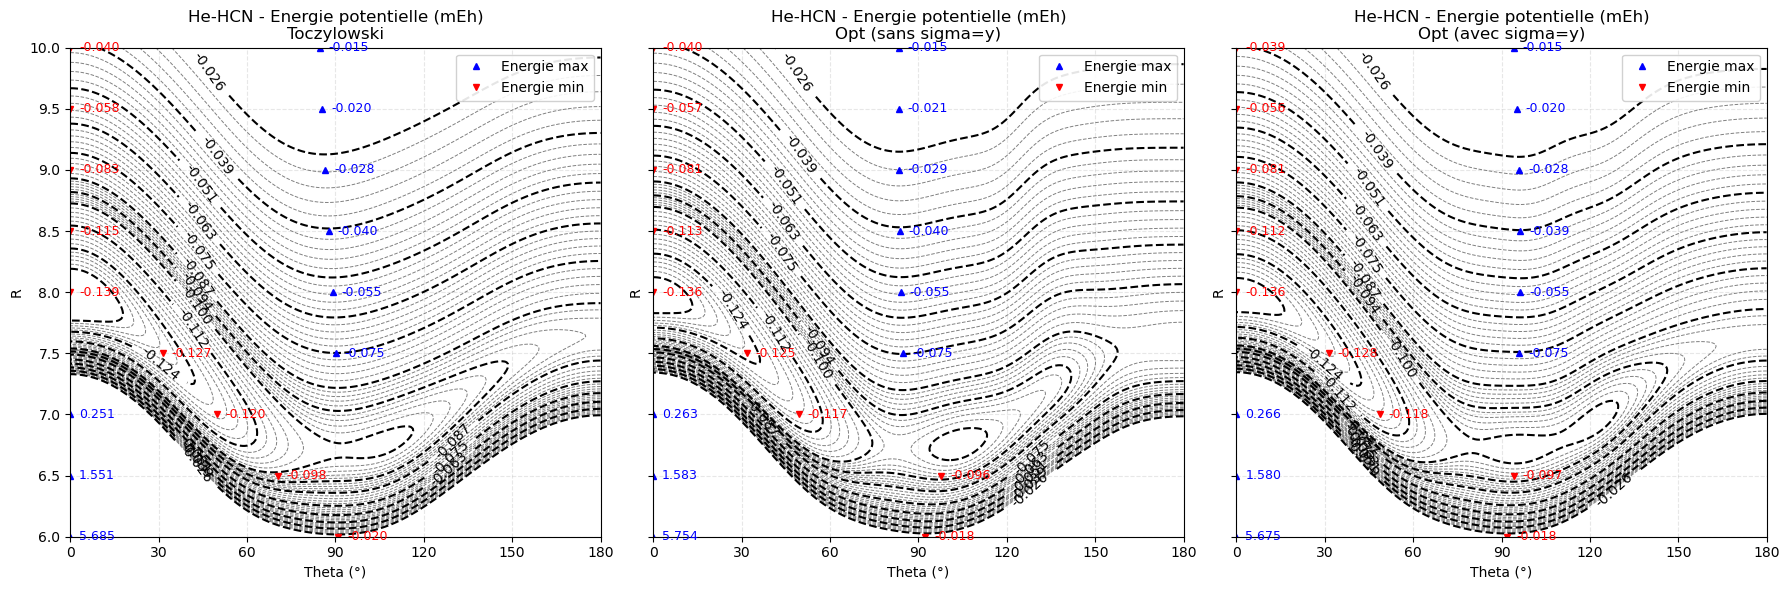

In [164]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

contour_plot(axes[0], params_He, "Toczylowski")
contour_plot(axes[1], params_opt_cf, "Opt (sans sigma=y)")
contour_plot(axes[2], params_opt_cf_sigma, "Opt (avec sigma=y)")

plt.tight_layout()

## Plot en 3D

# Methode 2 : least_squares


In [20]:
def residus_He(params):
    V_pred = V_opt(params, He["R"], He["Theta"])
    # .ravel() force le résultat en un tableau 1D pour least_squares
    return (V_pred - He["Energy_mEh"]).ravel()

In [21]:
result1 = least_squares(residus_He, params_He)
params_opt_ls = result1.x

result2 = least_squares(residus_He, params_He, x_scale = "jac")
params_opt_ls_jac = result2.x

In [22]:
result3 = least_squares(residus_He, params_He, 
                        x_scale = "jac", loss="soft_l1")
params_opt_ls_jac_soft = result3.x

In [23]:
result4 = least_squares(residus_He, params_He, 
                        x_scale = "jac", loss="huber")
params_opt_ls_jac_huber = result4.x

In [24]:
V_pred_ls = V_opt(params_opt_ls, R, Theta)
V_pred_ls_jac = V_opt(params_opt_ls_jac, R, Theta)
V_pred_ls_jac_soft = V_opt(params_opt_ls_jac_soft, R, Theta)
V_pred_ls_jac_huber = V_opt(params_opt_ls_jac_huber, R, Theta)

r2_ls = rsq(V_table_mEh, V_pred_ls)
r2_ls_jac = rsq(V_table_mEh, V_pred_ls_jac)
r2_ls_jac_soft = rsq(V_table_mEh, V_pred_ls_jac_soft)
r2_ls_jac_huber = rsq(V_table_mEh, V_pred_ls_jac_huber)

rmse_ls = rmse(V_table_mEh, V_pred_ls)
rmse_ls_jac = rmse(V_table_mEh, V_pred_ls_jac)
rmse_ls_jac_soft = rmse(V_table_mEh, V_pred_ls_jac_soft)
rmse_ls_jac_huber = rmse(V_table_mEh, V_pred_ls_jac_huber)

mae_ls = mae(V_table_mEh, V_pred_ls)
mae_ls_jac = mae(V_table_mEh, V_pred_ls_jac)
mae_ls_jac_soft = mae(V_table_mEh, V_pred_ls_jac_soft)
mae_ls_jac_huber = mae(V_table_mEh, V_pred_ls_jac_huber)

print(f"R²                                   : {r2_ls}")
print(f"R²   (x_scale='jac')                 : {r2_ls_jac}")
print(f"R²   (x_scale='jac', 'loss=soft_l1') : {r2_ls_jac_soft}")
print(f"R²   (x_scale='jac', 'loss=huber')   : {r2_ls_jac_huber}")
print()
print(f"rmse                                 : {rmse_ls}")
print(f"rmse (x_scale='jac')                 : {rmse_ls_jac}")
print(f"rmse (x_scale='jac', loss='soft_l1') : {rmse_ls_jac_soft}")
print(f"rmse (x_scale='jac', loss='huber')   : {rmse_ls_jac_huber}")
print()
print(f"mae                                  : {mae_ls}")
print(f"mae  (x_scale='jac')                 : {mae_ls_jac}")
print(f"mae  (x_scale='jac', loss='soft_l1') : {mae_ls_jac_soft}")
print(f"mae  (x_scale='jac', loss='huber')   : {mae_ls_jac_huber}")

R²                                   : 0.9999979337986399
R²   (x_scale='jac')                 : 0.9999998710239754
R²   (x_scale='jac', 'loss=soft_l1') : 0.9999999004185103
R²   (x_scale='jac', 'loss=huber')   : 0.9999999004185094

rmse                                 : 0.002961672504821794
rmse (x_scale='jac')                 : 0.0007399548230815067
rmse (x_scale='jac', loss='soft_l1') : 0.0006501896044096505
rmse (x_scale='jac', loss='huber')   : 0.0006501896072691503

mae                                  : 0.0017277451373269373
mae  (x_scale='jac')                 : 0.0005812989582115011
mae  (x_scale='jac', loss='soft_l1') : 0.0004947063555608599
mae  (x_scale='jac', loss='huber')   : 0.0004947070047232251


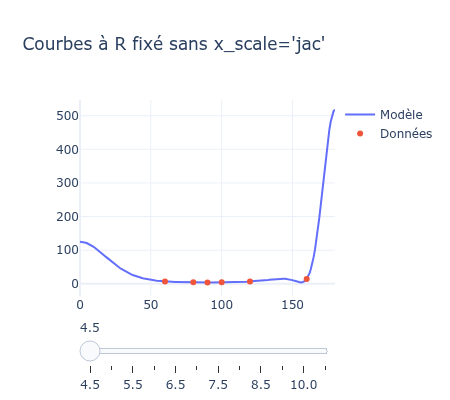

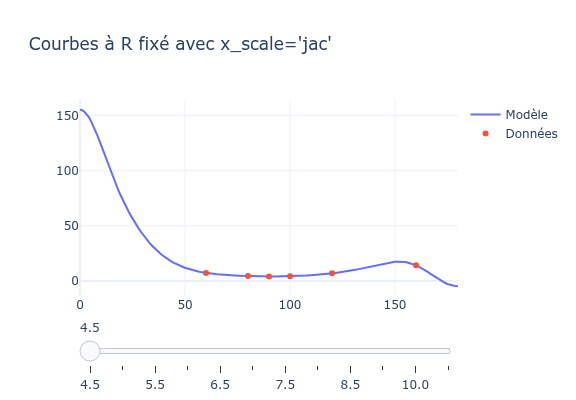

In [25]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_ls, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, params_opt_ls_jac, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec x_scale='jac'")

## Variation des params initiaux

In [26]:
def metriques(y, y_pred, params):

  residus = y - y_pred

  rss = np.sum(residus**2)
  tss = np.sum((y - np.mean(y))**2)
  r2 = 1 - rss/tss

  mae = np.mean(np.abs(residus))
  rmse = np.sqrt(np.mean(residus**2))
  param_norm = np.linalg.norm(params)

  return {
      "rmse": rmse,
      "mae": mae,
      "r2": r2,
      "rss": rss,
      "param_norm": param_norm
      }

In [27]:
# import d'un calcul précédent de 'resultats'
with open("resultats_multistart.pkl", "rb") as f:
    resultats = pickle.load(f)

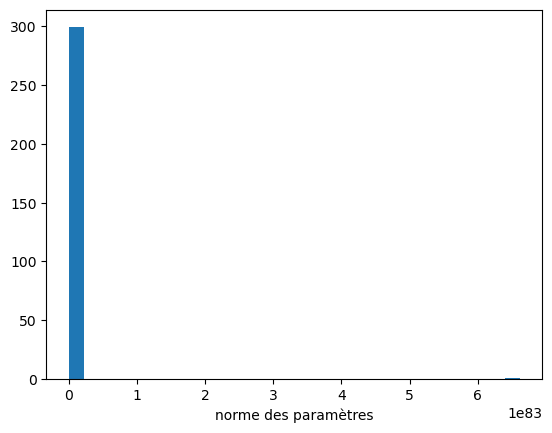

In [28]:
normes = [np.linalg.norm(r["params"]) for r in resultats]

plt.hist(normes, bins=30)
plt.xlabel("norme des paramètres")
plt.show()

In [43]:
# Tri avec rmse
best_rmse_fit = min(resultats, key=lambda r: r["rmse"])
# Solutions stables
bon = [r for r in resultats if r["rmse"] <= 1.10 * best_rmse_fit["rmse"]]

bon_r2 = [r for r in resultats if r["r2"] > 0.999999]

# On récupère tous les "bons" paramètres
params_all = np.array([r["params"] for r in bon])
# On regarde la distribution des paramètres pour
# voir s'ils sont proches
params_std = np.std(params_all, axis=0)

In [54]:
best_r2 = min(bon_r2, key=lambda r: r["mae"])
best_r2

{'params': array([ 2.16976644e+00, -8.56540259e-01,  5.44247701e-01, -6.35182204e-02,
        -1.47009717e-01, -4.78693993e-02, -1.99345245e+04, -2.31230265e+04,
        -1.05827934e+04, -1.78498477e+04,  1.05704333e+01, -4.50466617e+00,
         4.69038121e+00, -5.68216336e-02, -5.84212476e-01, -2.01865288e-01,
        -2.27842230e+01,  4.94802125e+01, -8.90024690e+01,  9.26372560e+01,
        -4.45131927e+01,  4.48792740e+01,  1.68383897e+01, -2.71082809e+01,
         5.37279037e+01, -5.68472088e+01,  2.89953166e+01, -2.10270671e+01,
        -3.34907448e+00,  5.95915835e+00, -1.12450358e+01,  1.14683309e+01,
        -5.91277676e+00,  3.21110444e+00,  2.27866386e-01, -4.81250611e-01,
         8.00881675e-01, -7.60955135e-01,  3.81311927e-01, -1.59748287e-01]),
 'rmse': np.float64(0.0006095942645154914),
 'mae': np.float64(0.0004404609293272692),
 'r2': np.float64(0.9999999124652853),
 'rss': np.float64(5.128151309156524e-05),
 'param_norm': np.float64(36914.8289402298)}

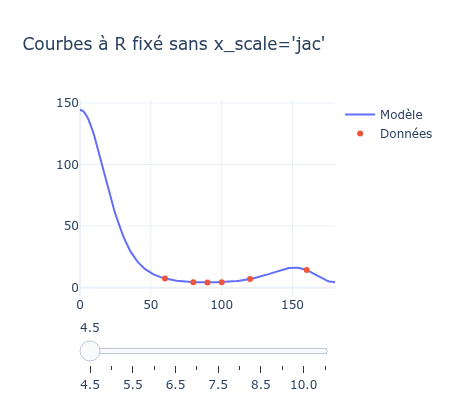

In [165]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, best_r2["params"], R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")

In [72]:
precis = least_squares(residus_He, params_all[1], method="trf",
                       loss="huber", x_scale="jac", max_nfev=200000,
                       xtol=1e-12, ftol=1e-12, gtol=1e-12)

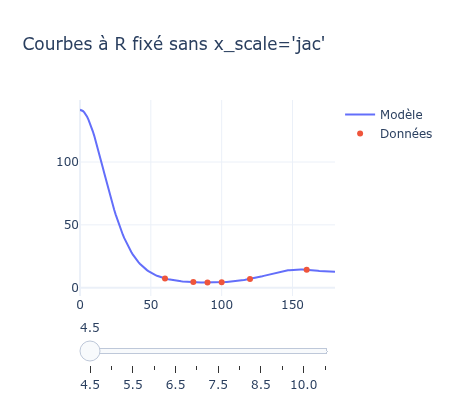

In [73]:
plot_interactif(V_opt, precis.x, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")

# Methode 3 : Differential_evolution + least_squares

In [76]:
def cout(params):
    V_pred = V_opt(params,He["R"],He["Theta"])
    resid = V_pred - He["Energy_mEh"]
    return np.mean(resid**2)

In [82]:
# On récupère les bounds à l'aide des meilleurs params
p_min = np.min(params_all, axis=0)
p_max = np.max(params_all, axis=0)
# On ajoute une marge
a = p_min - 0.2 * np.maximum(np.abs(p_min), 1e-2)
b = p_max + 0.2 * np.maximum(np.abs(p_max), 1e-2)
# Bounds
bounds = list(zip(a, b))

In [95]:
result_de = differential_evolution(
    cout,
    bounds,
    strategy="best1bin",
    maxiter=300,
    popsize=20,
    workers=-1,
    polish=False,
    disp=True
)

/home/amynek/anaconda3/envs/jupyter-2026/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:518: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


differential_evolution step 1: f(x)= 17.55130748520364
differential_evolution step 2: f(x)= 12.54971880068579
differential_evolution step 3: f(x)= 12.54971880068579
differential_evolution step 4: f(x)= 4.745911743024117
differential_evolution step 5: f(x)= 4.745911743024117
differential_evolution step 6: f(x)= 3.8888922180316823
differential_evolution step 7: f(x)= 3.8888922180316823
differential_evolution step 8: f(x)= 3.8888922180316823
differential_evolution step 9: f(x)= 3.8888922180316823
differential_evolution step 10: f(x)= 3.8888922180316823
differential_evolution step 11: f(x)= 3.642807380838063
differential_evolution step 12: f(x)= 3.44994166548501
differential_evolution step 13: f(x)= 2.4068779644713496
differential_evolution step 14: f(x)= 1.9146470709119612
differential_evolution step 15: f(x)= 1.9146470709119612
differential_evolution step 16: f(x)= 1.9146470709119612
differential_evolution step 17: f(x)= 1.9146470709119612
differential_evolution step 18: f(x)= 1.91464707

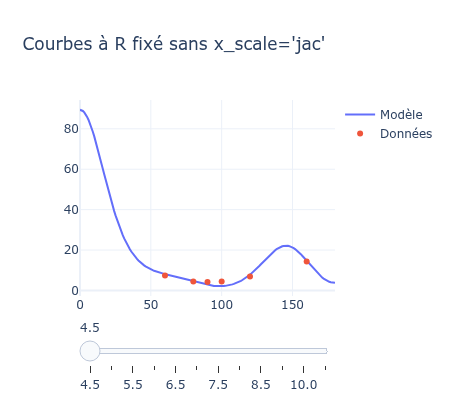

In [96]:
plot_interactif(V_opt, result_de.x, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")

In [108]:
result_ls_affinage = least_squares(
    residus_He,
    result_de.x,
    method="lm",
    loss="linear",
    x_scale=None,
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
    max_nfev=100000
)

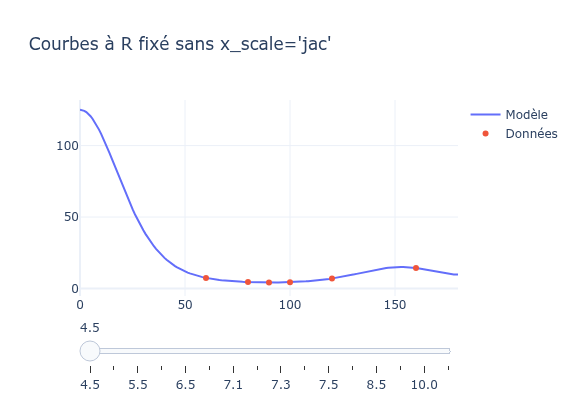

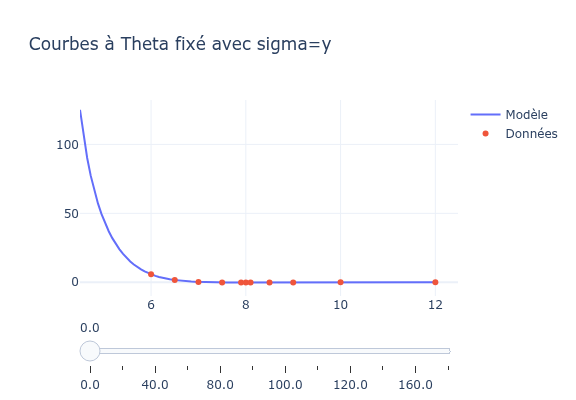

In [113]:
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4.5, 12, 100)
plot_interactif(V_opt, result_ls_affinage.x, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, result_ls_affinage.x, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé avec sigma=y",fixed_first=False)

# R progressif

In [148]:
He1 = He[He["R"] >= 9]
He2 = He[He["R"] >= 7]
He3 = He[He["R"] >= 4]
p0 = params_He

In [134]:
def residus1(params):
    V_pred = V_opt(params, He1["R"], He1["Theta"])
    return V_pred - He1["Energy_mEh"]
def residus2(params):
    V_pred = V_opt(params, He2["R"], He2["Theta"])
    return V_pred - He2["Energy_mEh"]
def residus3(params):
    V_pred = V_opt(params, He3["R"], He3["Theta"])
    return V_pred - He3["Energy_mEh"]

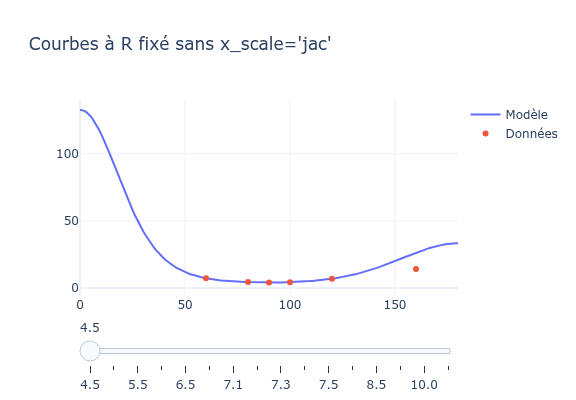

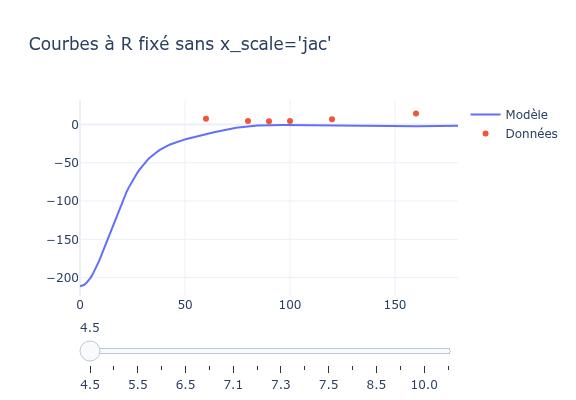

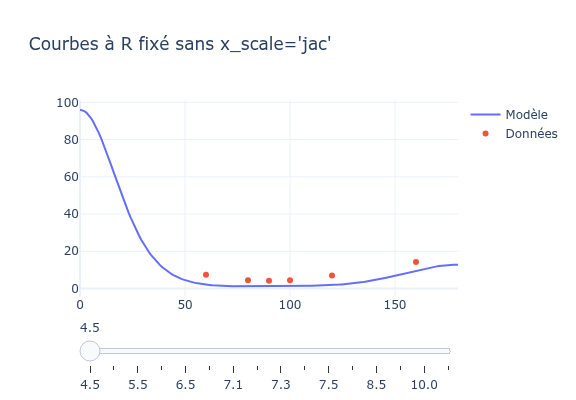

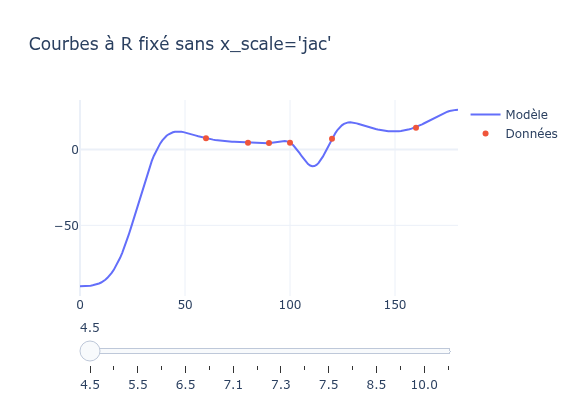

In [149]:
resultRD1 = least_squares(residus1, p0, x_scale = "jac")
p1 = resultRD1.x
resultRD2 = least_squares(residus2, p1, x_scale = "jac")
p2 = resultRD2.x
resultRD3 = least_squares(residus3, p2, x_scale = "jac")
p3 = resultRD3.x

plot_interactif(V_opt, p0, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, p1, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, p2, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, p3, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")

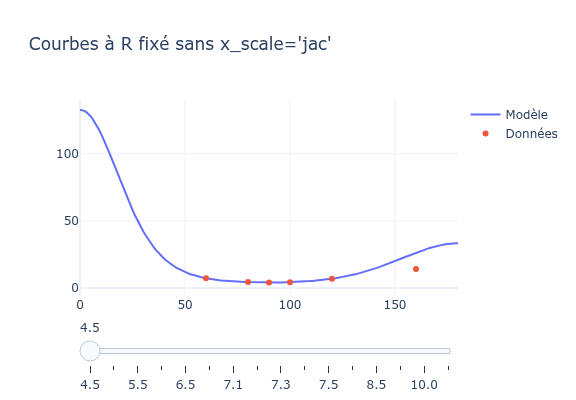

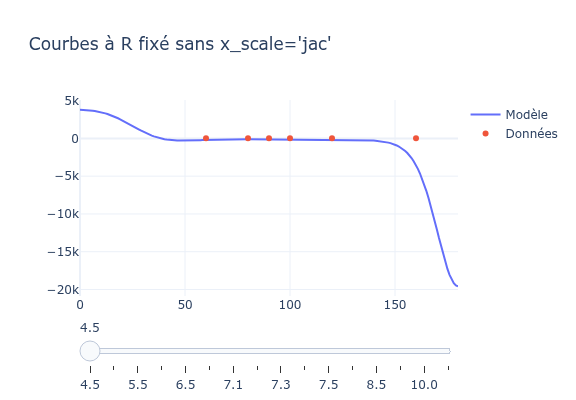

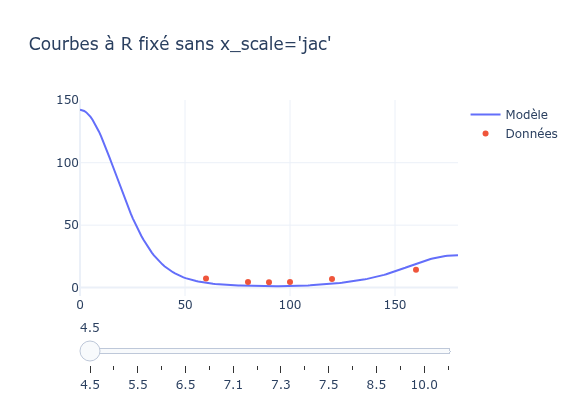

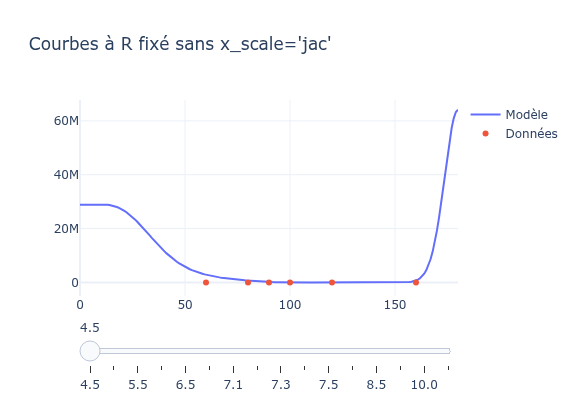

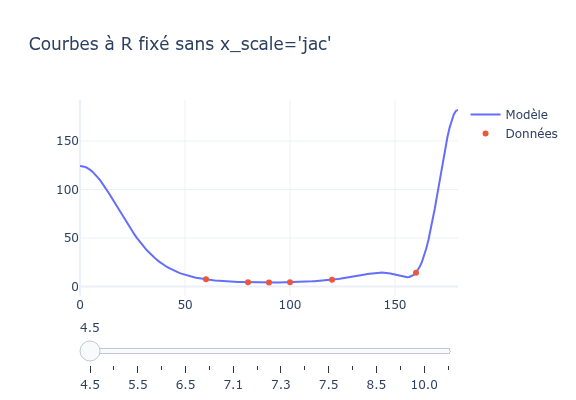

In [150]:
resultRD1 = least_squares(residus1, p0)
p1 = resultRD1.x
resultRD2 = least_squares(residus2, p1)
p2 = resultRD2.x
resultRD2b = least_squares(residus1, p2)
p2b = resultRD2b.x
resultRD3 = least_squares(residus3, p2b)
p3 = resultRD3.x

plot_interactif(V_opt, p0, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, p1, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, p2, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, p2b, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, p3, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")